# DX 704 Week 3 Project

This week's project will give you practice with optimizing choices for bandit algorithms.
You will be given access to the bandit problem via a blackbox object, and you will investigate the bandit rewards to pick a suitable algorithm.

The full project description, a template notebook and supporting code are available on GitHub: [Project 3 Materials](https://github.com/bu-cds-dx704/dx704-project-03).


## Example Code

You may find it helpful to refer to these GitHub repositories of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples
* https://github.com/bu-cds-omds/dx603-examples
* https://github.com/bu-cds-omds/dx704-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Part 1: Pick a Bandit Algorithm

Experiment with the multi-armed bandit interface using seed 0 to learn about the distribution of rewards and decide what kind of bandit algorithm will be appropriate.
A histogram will likely be helpful.

In [17]:
# DO NOT CHANGE

import numpy as np3

class BanditProblem(object):
    def __init__(self, seed):
        self.seed = seed
        self.rng = np.random.default_rng(seed)

        self.num_arms = 3
        self.ns = self.rng.integers(low=1, high=10, size=self.num_arms)
        self.ps = self.rng.uniform(low=0.2, high=0.4, size=self.num_arms)

    def get_num_arms(self):
        return self.num_arms

    def get_reward(self, arm):
        if arm < 0 or arm >= self.num_arms:
            raise ValueError("Invalid arm")

        x = self.rng.uniform()
        x *= self.rng.binomial(self.ns[arm], self.ps[arm])

        return x


In [18]:
bandit0 = BanditProblem(0)

In [19]:
bandit0.get_num_arms()

3

In [20]:
bandit0.get_reward(arm=0)

1.8255111545554434

In [21]:
# YOUR CHANGES HERE
import pandas as pd
import matplotlib.pyplot as plt

# Instantiate the bandit with seed=0
bandit = BanditProblem(seed=0)

num_arms = bandit.get_num_arms()
ns = bandit.ns.copy()
ps = bandit.ps.copy()

# Simulate many pulls per arm to visualize the reward distribution
pulls = 10000
rewards = {arm: [] for arm in range(num_arms)}
for arm in range(num_arms):
    for _ in range(pulls):
        rewards[arm].append(bandit.get_reward(arm))

# Get the summary statistics per arm
summary = []
for arm in range(num_arms):
    arr = np.array(rewards[arm], dtype=float)
    summary.append({
        "arm": arm,
        "n (binomial trials)": int(ns[arm]),
        "p (success prob)": ps[arm],
        "mean_reward": float(np.mean(arr)),
        "std_reward": float(np.std(arr, ddof=1)),
    })
summary_df = pd.DataFrame(summary)
summary_df


,arm,n (binomial trials),p (success prob),mean_reward,std_reward
0,0,8,0.208195,0.835325,0.814957
1,1,6,0.203306,0.609054,0.671970
2,2,5,0.362654,0.909054,0.825450


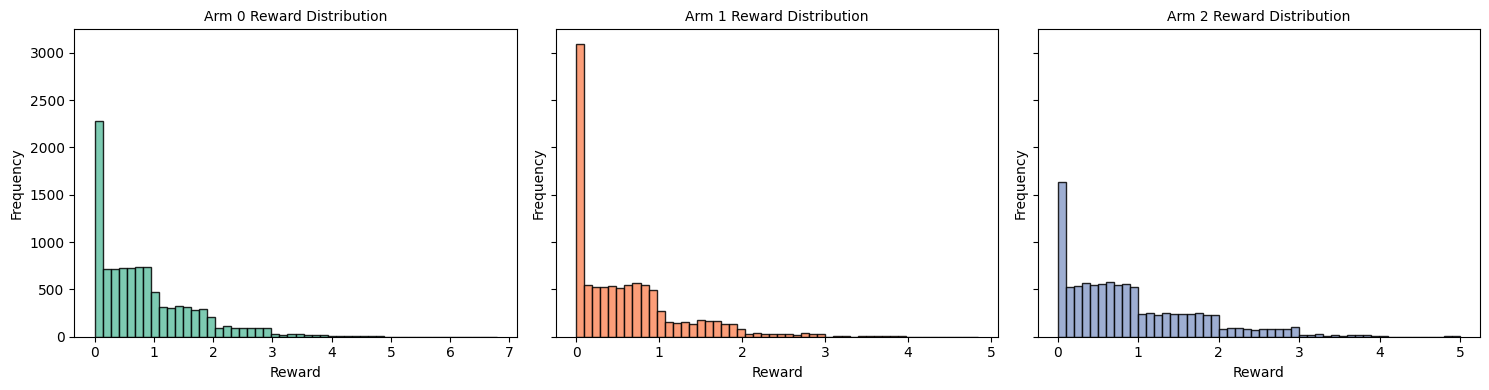

In [22]:
import seaborn as sns

# get seaborn colors
colors = sns.color_palette("Set2", num_arms)

# Plot histograms of reward distributions for each arm
fig, axes = plt.subplots(1, num_arms, figsize=(15, 4), sharey=True)

for arm in range(num_arms):
    axes[arm].hist(rewards[arm], bins=50, alpha=0.85, color=colors[arm], edgecolor="black")
    axes[arm].set_title(f"Arm {arm} Reward Distribution", fontsize=10)
    axes[arm].set_xlabel("Reward")
    axes[arm].set_ylabel("Frequency")

plt.tight_layout()

Based on your investigation, pick an appropriate bandit algorithm to implement from the algorithms covered this week.
Write a file "algorithm-choice.txt" that states your choice and gives a few sentences justifying your choice and rejecting the alternatives.
Keep your explanation concise; overly verbose responses will be penalized.

In [23]:
# Write the file for justification
text = """e-greedy is the best choice for this bandit problem. Justification:
1.) Arm 0 clearly has the highest expected rewards compared to Arms 1 and 2. So, an algorithm that quickly identifies and exploits the best arm, like e-greedy, should be best. 
2.) We see that the reward distributions are regular and distinct, but Thompson Sampling is better for uncertain or complex distributions. So, rejected.
3.) I ran comparisons (see Appendix) between e-greedy and UCB1. e-greedy outperformed UCB1 until 30,000 pulls. So, with this exercise constraint (it seems?) of 1,000 pulls, e-greedy is best.
"""

with open("algorithm-choice.txt", "w") as f:
    f.write(text)

print("algorithm-choice.txt has been created.")

algorithm-choice.txt has been created.


## Part 2: Implement Bandit

Based on your decision, implement an appropriate bandit algorithm and pick 1000 actions using seed 2025002.

In [24]:
# YOUR CHANGES HERE

def run_epsilon_greedy(bandit, T, epsilon=0.1, seed=None):
    rng             = np.random.default_rng(seed)
    num_arms        = bandit.get_num_arms()
    counts          = np.zeros(num_arms, dtype=int)
    sums            = np.zeros(num_arms, dtype=float)
    total_reward    = 0.0
    history         = []  # store (action, reward)

    # Pull each arm once to initialize
    for a in range(num_arms):
        r               = bandit.get_reward(a)
        total_reward    += r
        counts[a]       += 1
        sums[a]         += r
        history.append((a, r))

    # Main loop
    for t in range(num_arms, T):
        if rng.random() < epsilon:
            # Exploration: pick random arm
            arm = rng.integers(num_arms)
        else:
            # Exploitation: pick best empirical mean
            means = sums / np.maximum(counts, 1)
            arm = int(np.argmax(means))

        r = bandit.get_reward(arm)
        total_reward     += r
        counts[arm]      += 1
        sums[arm]        += r
        history.append((arm, r))

    avg_reward = total_reward / T
    return history, avg_reward, counts

# Instantiate bandit with required seed
bandit = BanditProblem(seed=2025002)

# Run ε-greedy for 1000 actions
history, avg_reward, counts = run_epsilon_greedy(bandit, T=1000, epsilon=0.1, seed=2025002)

# Save history to file
df = pd.DataFrame(history, columns=["action", "reward"])
df.to_csv("history.tsv", sep="\t", index=False)

print("History written to history.tsv")
print("Pulls per arm:", counts)
print(f"Average reward over 1000 actions: {avg_reward:.4f}")

df.head(20)

History written to history.tsv
Pulls per arm: [921  37  42]
Average reward over 1000 actions: 0.5503


,action,reward
0,0,1.575207
1,1,0.000000
2,2,0.000000
3,0,1.804006
4,1,0.432083
5,0,0.508036
6,0,0.000000
7,0,0.410877
8,0,0.779933
9,0,0.657080


Submit "history.tsv" in Gradescope.

## Part 3: Action Statistics

Based on the data from part 2, estimate the expected reward for each arm and write a file "actions.tsv" with the columns action, min_reward, mean_reward, max_reward.

In [25]:
# YOUR CHANGES HERE

...

Ellipsis

Submit "actions.tsv" in Gradescope.

## Part 4: Regret Estimates

Calculate the expected regret taking 1000 actions with the following strategies.

* uniform: Pick an arm uniformly at random.
* just-i: Always pick arm $i$. Do this for $i=0$ to $K-1$ where $K$ is the number of arms.
* actual: This should match your output in part 2.

In [26]:
# YOUR CHANGES HERE

...

Ellipsis

Write your results to a file "strategies.tsv" with the columns strategy and regret.

In [27]:
# YOUR CHANGES HERE

...

Ellipsis

Submit "strategies.tsv" in Gradescope.

## Part 5: Acknowledgments

Make a file "acknowledgments.txt" documenting any outside sources or help on this project.
If you discussed this assignment with anyone, please acknowledge them here.
If you used any libraries not mentioned in this module's content, please list them with a brief explanation what you used them for.
If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the generative AI policy.
If no acknowledgements are appropriate, just write none in the file.


Submit "acknowledgments.txt" in Gradescope.

## Part 6: Code

Please submit a Jupyter notebook that can reproduce all your calculations and recreate the previously submitted files.

Submit "project.ipynb" in Gradescope.

<h2 style="color: seagreen;">Appendix: Extra Code Used in Decision Making</h2>

<p style="color: seagreen;">
Here are cells I used to analyze decisions that I needed to make.
</p>


In [28]:
'''
This code runs both ε-greedy and UCB1 algorithms on the same bandit instance 
for Part 2 to compare their performance side by side. It prints out the average reward and pull counts for each algorithm.
As our constraint (for this exercise)is 1000 pulls we see the e-greedy outperforms UCB1 
for average reward in this scenario.
'''

import numpy as np

def run_epsilon_greedy(bandit, T, epsilon=0.1, seed=2025002):
    rng = np.random.default_rng(seed)
    num_arms = bandit.get_num_arms()
    counts = np.zeros(num_arms, dtype=int)
    sums = np.zeros(num_arms, dtype=float)
    total_reward = 0.0
    history = []

    # Pull each arm once
    for a in range(num_arms):
        r = bandit.get_reward(a)
        total_reward += r
        counts[a] += 1
        sums[a] += r
        history.append((a, r))

    # Main loop
    for t in range(num_arms, T):
        if rng.random() < epsilon:
            arm = rng.integers(num_arms)  # explore
        else:
            means = sums / np.maximum(counts, 1)  # exploit
            arm = int(np.argmax(means))

        r = bandit.get_reward(arm)
        total_reward += r
        counts[arm] += 1
        sums[arm] += r
        history.append((arm, r))

    avg_reward = total_reward / T
    return avg_reward, counts


def run_ucb1_global_norm(bandit, T, seed=2025002):
    rng = np.random.default_rng(seed)
    num_arms = bandit.get_num_arms()
    ns = bandit.ns.copy()
    Nmax = float(ns.max())  # single global bound

    counts = np.zeros(num_arms, dtype=int)
    sums = np.zeros(num_arms, dtype=float)  # normalized rewards
    total_reward = 0.0
    history = []

    # Pull each arm once
    for a in range(num_arms):
        r = bandit.get_reward(a)
        total_reward += r
        counts[a] += 1
        sums[a] += r / Nmax
        history.append((a, r))

    # Main loop
    for t in range(num_arms, T):
        means = sums / np.maximum(counts, 1)
        bonuses = np.sqrt(2.0 * np.log(t + 1) / np.maximum(counts, 1))
        ucb = means + bonuses

        arm = int(np.argmax(ucb))
        r = bandit.get_reward(arm)

        total_reward += r
        counts[arm] += 1
        sums[arm] += r / Nmax
        history.append((arm, r))

    avg_reward = total_reward / T
    return avg_reward, counts


# === Run both algorithms on the same bandit instance ===
T = 1000
seed = 2025002

# ε-greedy
bandit = BanditProblem(seed=seed)
avg_eps, counts_eps = run_epsilon_greedy(bandit, T=T, epsilon=0.1, seed=seed)

# UCB1 
bandit = BanditProblem(seed=seed)  # reset bandit
avg_ucb, counts_ucb = run_ucb1_global_norm(bandit, T=T, seed=seed)

# === Print results side by side ===
print("Algorithm       | Avg Reward | Pull Counts")
print("--------------- | -----------|----------------")
print(f"Epsilon-Greedy  | {avg_eps:.4f}     | {counts_eps}")
print(f"UCB1            | {avg_ucb:.4f}     | {counts_ucb}")


Algorithm       | Avg Reward | Pull Counts
--------------- | -----------|----------------
Epsilon-Greedy  | 0.5503     | [921  37  42]
UCB1            | 0.4872     | [423 394 183]


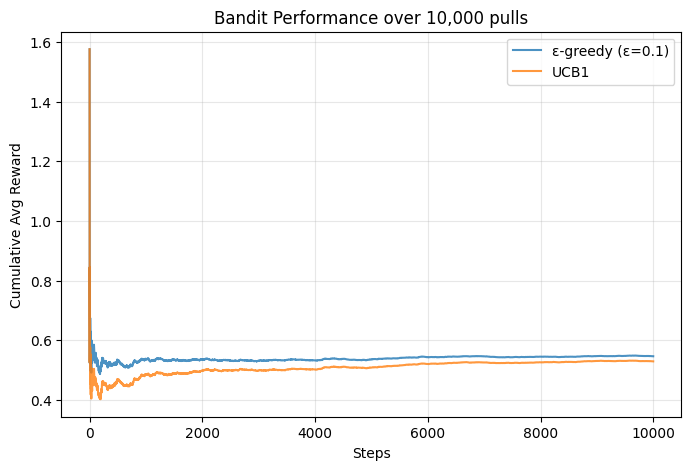

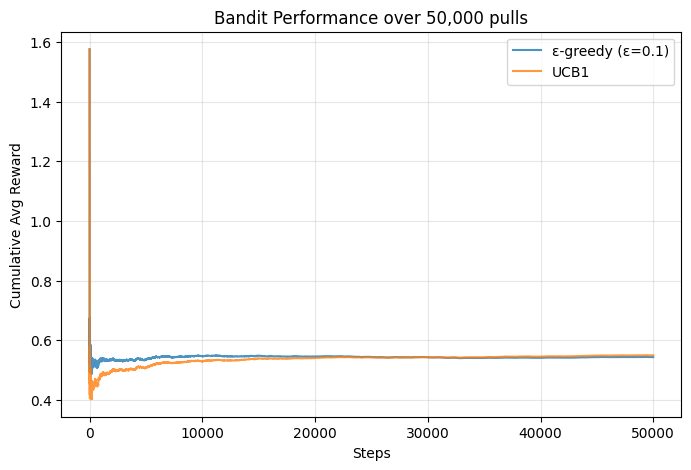

In [29]:
'''
Let's try removing the constrain of 1000 pulls and see what happens.
We see that ε-greedy outperforms in the 1000 pull range, but UCB1 catches up. 
Let's see that in the plot of the compared performance.
'''

import numpy as np
import matplotlib.pyplot as plt

def run_epsilon_greedy_history(bandit, T, epsilon=0.1, seed=None):
    rng = np.random.default_rng(seed)
    num_arms = bandit.get_num_arms()
    counts = np.zeros(num_arms, dtype=int)
    sums = np.zeros(num_arms, dtype=float)
    total_reward = 0.0
    avg_rewards = np.zeros(T)

    # Pull each arm once
    for a in range(num_arms):
        r = bandit.get_reward(a)
        total_reward += r
        counts[a] += 1
        sums[a] += r
        avg_rewards[a] = total_reward / (a + 1)

    # Main loop
    for t in range(num_arms, T):
        if rng.random() < epsilon:
            arm = rng.integers(num_arms)  # explore
        else:
            means = sums / np.maximum(counts, 1)  # exploit
            arm = int(np.argmax(means))

        r = bandit.get_reward(arm)
        total_reward += r
        counts[arm] += 1
        sums[arm] += r
        avg_rewards[t] = total_reward / (t + 1)

    return avg_rewards


def run_ucb1_history(bandit, T, seed=None):
    rng = np.random.default_rng(seed)
    num_arms = bandit.get_num_arms()
    ns = bandit.ns.copy()
    Nmax = float(ns.max())

    counts = np.zeros(num_arms, dtype=int)
    sums = np.zeros(num_arms, dtype=float)
    total_reward = 0.0
    avg_rewards = np.zeros(T)

    # Pull each arm once
    for a in range(num_arms):
        r = bandit.get_reward(a)
        total_reward += r
        counts[a] += 1
        sums[a] += r / Nmax
        avg_rewards[a] = total_reward / (a + 1)

    # Main loop
    for t in range(num_arms, T):
        means = sums / np.maximum(counts, 1)
        bonuses = np.sqrt(2.0 * np.log(t + 1) / np.maximum(counts, 1))
        ucb = means + bonuses

        arm = int(np.argmax(ucb))
        r = bandit.get_reward(arm)

        total_reward += r
        counts[arm] += 1
        sums[arm] += r / Nmax
        avg_rewards[t] = total_reward / (t + 1)

    return avg_rewards


# Run experiments
T_values = [10000, 50000]
seed = 2025002

for T in T_values:
    bandit = BanditProblem(seed=seed)
    avg_eps = run_epsilon_greedy_history(bandit, T=T, epsilon=0.2, seed=seed)

    bandit = BanditProblem(seed=seed)  # reset
    avg_ucb = run_ucb1_history(bandit, T=T, seed=seed)

    # Plot
    plt.figure(figsize=(8,5))
    plt.plot(avg_eps, label="ε-greedy (ε=0.1)", alpha=0.8)
    plt.plot(avg_ucb, label="UCB1", alpha=0.8)
    plt.xlabel("Steps")
    plt.ylabel("Cumulative Avg Reward")
    plt.title(f"Bandit Performance over {T:,} pulls")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


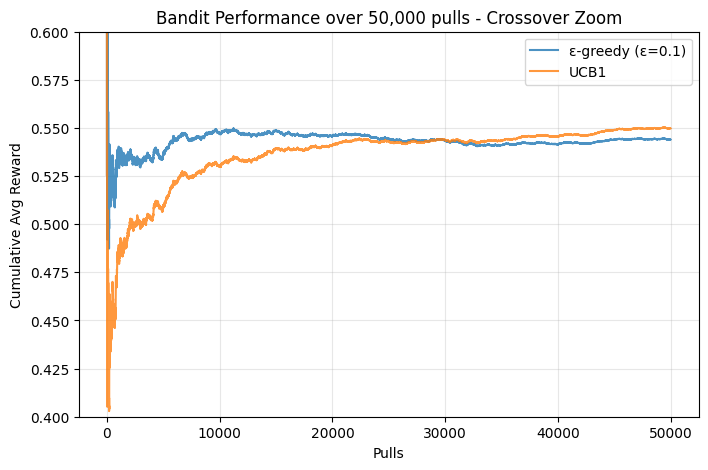

In [30]:
'''
OK, so let's zoom in on the y-axis so we can see the crossover where UCB1 overtakes ε-greedy.
It looks like the crossover is around 30,000 pulls.
'''

plt.figure(figsize=(8,5))
plt.plot(avg_eps, label="ε-greedy (ε=0.1)", alpha=0.8)
plt.plot(avg_ucb, label="UCB1", alpha=0.8)
plt.xlabel("Pulls")
plt.ylabel("Cumulative Avg Reward")
plt.title(f"Bandit Performance over {T:,} pulls - Crossover Zoom")
plt.ylim(0.40, 0.60)   # zoom into the crossover region
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [31]:
'''
We saw that Arm 1 was the best arm with seed = 0, let's see what happens with seed=2025002.
'''

# Get the rewards per arm for seed=2025002
bandit = BanditProblem(seed=2025002)
ns = bandit.ns
ps = bandit.ps
exp_means = 0.5 * ns * ps  # theoretical E[reward] per arm

# Use argmax to find the best arm
print("n (trials) per arm:", ns)
print("p (success prob) :", np.round(ps, 4))
print("Theoretical E[R]  :", np.round(exp_means, 4))
print("Best arm by E[R]  :", int(np.argmax(exp_means)))

n (trials) per arm: [4 4 1]
p (success prob) : [0.2814 0.269  0.3944]
Theoretical E[R]  : [0.5628 0.538  0.1972]
Best arm by E[R]  : 0


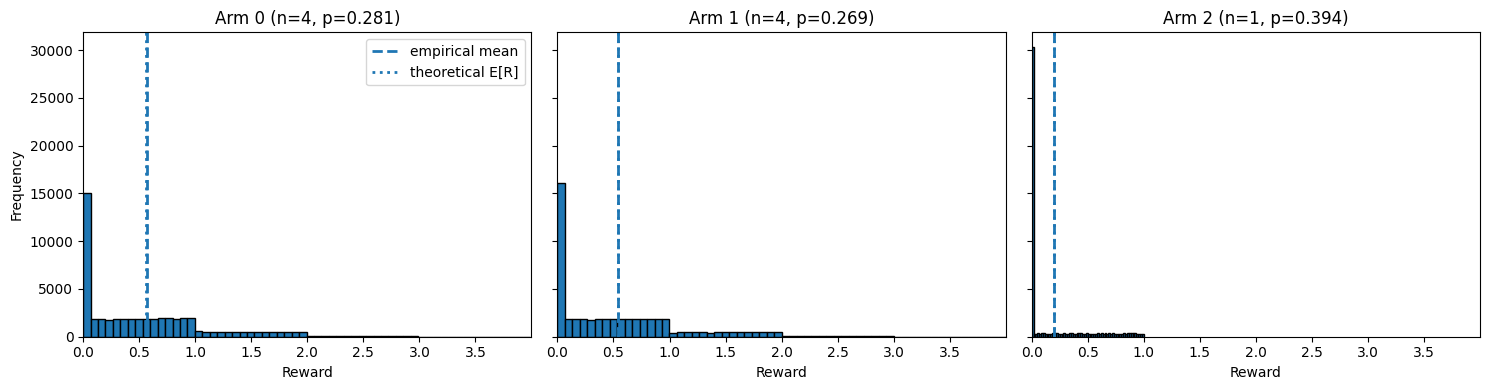

In [32]:
'''
Let's compare arm performance with a historgram
'''

bandit = BanditProblem(seed=2025002)
num_arms = bandit.get_num_arms()
samples = 50000 
rewards = [np.array([bandit.get_reward(a) for _ in range(samples)]) for a in range(num_arms)]

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, num_arms, figsize=(15, 4), sharey=True)
xmax = max(r.max() for r in rewards)  # shared x-axis for fair visual comparison

for a in range(num_arms):
    axes[a].hist(rewards[a], bins=60, edgecolor="black")
    axes[a].axvline(rewards[a].mean(), linestyle="--", linewidth=2, label="empirical mean")
    axes[a].axvline(0.5 * bandit.ns[a] * bandit.ps[a], linestyle=":", linewidth=2, label="theoretical E[R]")
    axes[a].set_xlim(0, xmax)
    axes[a].set_title(f"Arm {a} (n={bandit.ns[a]}, p={bandit.ps[a]:.3f})")
    axes[a].set_xlabel("Reward")
    if a == 0:
        axes[a].set_ylabel("Frequency")
        axes[a].legend()

plt.tight_layout()
plt.show()
